In [2]:
import requests
import json

import numpy as np

import os
from urllib.request import urlretrieve
import earthaccess
from earthaccess import Auth, DataCollections, DataGranules, Store

from numpy.lib.stride_tricks import sliding_window_view

from tqdm import tqdm
from loguru import logger
from datetime import datetime

import pickle
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib as mpl

import torch
import torchvision.transforms as transforms

/home/rdaroya_umass_edu/miniconda3/envs/ann-ssc/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Download tiles

In [3]:
# fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b276/2866_T12RYQ_14.npy"
fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b415/7112_T52XDG_08.npy"
with open(fp, "rb") as f:
    npzfile = np.load(f)
    features = npzfile["features"]  # (512,512,6)
    tile_id = npzfile["tile_id"][()]
    date_str = npzfile["date_str"][()]
    space_group = npzfile["space_group"][()]
    crop_size = npzfile["crop_size"]
    left_coor = npzfile["left_coor"]
    top_coor = npzfile["top_coor"]
    print(tile_id, date_str, space_group, crop_size, left_coor, top_coor)

sample_id = fp.split("/")[-1].split("_")[0]
print(f"sample_id: {sample_id}")
fp_sampled_id = f"/scratch/workspace/rdaroya_umass_edu-water/github/ssc-integration/OPERA-data/sampled_per_tile_id/{sample_id}.npy"
with open(fp_sampled_id, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    group = [k for k in npzfile["links"] if k['datetime']==date_str]
assert len(group)==1
group = group[0]
group

T52XDG 20230614T040551Z b415 768 1140 2125
sample_id: 7112


{'datetime': '20230614T040551Z',
 'opera_link': 'https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/OPERA_L3_DSWX-HLS_PROVISIONAL_V1/OPERA_L3_DSWx-HLS_T52XDG_20230614T040551Z_20230616T122025Z_S2A_30_v1.0_B01_WTR.tif',
 'hls_link': 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T52XDG.2023165T040551.v2.0/HLS.S30.T52XDG.2023165T040551.v2.0.B01.tif'}

In [4]:

opera_bands = ["B01_WTR", "B03_CONF", "B08_SHAD", "B09_CLOUD"]
# landsat_bands = ["B02", "B03", "B04", "B05", "B06", "B07", "Fmask"] # landsat (B,G,R,NIR,SWIR1,SWIR2)
landsat_bands = [f"B{b:02d}" for b in range(1,12)] + ["Fmask"]
# sentinel_bands = ["B02", "B03", "B04", "B8A", "B11", "B12", "Fmask"]
sentinel_bands = [f"B{b:02d}" for b in range(1,13)] + ["B8A", "Fmask"]
print(sentinel_bands)

opera_downloads = []
hls_downloads = []
opera_link = group["opera_link"]
opera_sat = opera_link.split("_")[-5]
for b in opera_bands:
    link = opera_link.replace("B01_WTR", b)
    opera_downloads.append(link)

if opera_sat.startswith("L"):
    hls_bands = landsat_bands
else:
    hls_bands = sentinel_bands

hls_link = group["hls_link"]
for b in hls_bands:
    link = hls_link.replace("B01", b)
    hls_downloads.append(link)

['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B8A', 'Fmask']


In [5]:

logger.debug(f"Downloading {len(opera_downloads)} opera_downloads")
logger.debug(f"Downloading {len(hls_downloads)} hls_downloads")
earthaccess.download(opera_downloads, f"../opera_sample/opera")
earthaccess.download(hls_downloads, f"../opera_sample/hls")
logger.debug("Finished download")

2024-04-13 18:27:11.577 | DEBUG    | __main__:<module>:1 - Downloading 4 opera_downloads
2024-04-13 18:27:11.580 | DEBUG    | __main__:<module>:2 - Downloading 14 hls_downloads
QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 180.17it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:04<00:00,  1.15s/it]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 17313.95it/s]
QUEUEING TASKS | : 100%|██████████| 14/14 [00:00<00:00, 333.94it/s]
PROCESSING TASKS | : 100%|██████████| 14/14 [00:07<00:00,  1.94it/s]
COLLECTING RESULTS | : 100%|██████████| 14/14 [00:00<00:00, 26063.14it/s]
2024-04-13 18:27:26.107 | DEBUG    | __main__:<module>:5 - Finished download


# Predict on sample

In [2]:
filename = 'xgb_model.sav'
model = pickle.load(open(filename, 'rb'))

FEAT_SCALE_TYPE = "linear_scale"    # options: "linear_scale", "standardize"

input_cols= ['b1_min','b1_mean','b1_max','b1_std','b1_median','b1_count',
            'b2_min','b2_mean','b2_max','b2_std','b2_median','b3_min',
            'b3_mean','b3_max','b3_std','b3_median','b4_min','b4_mean',
            'b4_max','b4_std','b4_median','b10_min','b10_mean','b10_max',
            'b10_std','b10_median','b11_min','b11_mean','b11_max','b11_std',
            'b11_median','b12_min','b12_mean','b12_max','b12_std','b12_median',
            'b8a_min','b8a_mean','b8a_max','b8a_std','b8a_median','LorS'
            ]

median_cols=['b1_median','b2_median','b3_median',\
                 'b4_median','b10_median','b11_median',\
                 'b12_median','b8a_median']

qa_col = 'b1_count'

cloud_cover_col = 'cloud_cover'
cloud_cut_number=50 #eliminate tiles with over 50 percent cloud cover

mgrs_col = 'MGRS'
mgrs_cut_number=0.5 #over 0.5 is 1
    
output_col = 'tss_value'
output_cols = [output_col]

coords_cols= ['lat','lon']


In [3]:
train_ssc_orig = pd.read_csv("../data/opera_feats/train.csv")   # need this for normalizing constants
# test_ssc_orig = pd.read_csv("../opera_sample/000334.csv")
# fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b276/2866_T12RYQ_14.npy"
test_ssc_orig = pd.read_csv("../opera_sample/001258.csv")
fp = "/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b415/7112_T52XDG_08.npy"

train_ssc_orig = train_ssc_orig.dropna(subset = input_cols, how="any")
train_ssc = train_ssc_orig[coords_cols+input_cols+output_cols]
x_train = train_ssc[input_cols]
y_train = np.log(train_ssc[output_col])

test_ssc_orig = test_ssc_orig.dropna(subset = input_cols, how="any")
test_ssc = test_ssc_orig[input_cols]
x_test = test_ssc[input_cols]
# y_test = np.log(test_ssc[output_col])

if FEAT_SCALE_TYPE == "linear_scale":    # options: "linear_scale", "standardize"
    logger.debug("Normalizing features and labels")

    y_train = y_train.values.reshape((-1,))
    x_train = x_train[input_cols].to_numpy()
    x_test = x_test[input_cols].to_numpy()

    logger.debug(f"x_test: {x_test.shape}, max: {np.max(x_test)} min: {np.min(x_test)}. ")


    # Normalize features and labels based on the training data
    logger.debug("Apply linear scaling to labels and features")
    y_train_max, y_train_min = np.max(y_train), np.min(y_train)
    x_train_max, x_train_min = np.max(x_train, axis=0), np.min(x_train, axis=0)

    x_train_norm = (x_train-x_train_min)/(x_train_max - x_train_min)
    x_test_norm = (x_test-x_train_min)/(x_train_max - x_train_min)

    # y_train_norm = (y_train - y_train_min)/(y_train_max-y_train_min)    # NOTE: need to un-normalize predictions for validation and test sets


2024-04-11 14:47:40.280 | DEBUG    | __main__:<module>:15 - Normalizing features and labels
2024-04-11 14:47:40.299 | DEBUG    | __main__:<module>:21 - x_test: (23832, 42), max: 4833.0 min: -167.0. 
2024-04-11 14:47:40.301 | DEBUG    | __main__:<module>:25 - Apply linear scaling to labels and features


In [4]:

test_pred = model.predict(x_test_norm)
if FEAT_SCALE_TYPE == "standardize":
    test_pred = (test_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    test_pred = (test_pred*(y_train_max-y_train_min)) + y_train_min
test_pred = np.exp(test_pred)


In [5]:
def prepare_inp_data(features, nodata_val=-9999):
    feats_tmp = np.where(features==nodata_val, np.nanmax(features), features)
    feats_min = np.nanmin(feats_tmp)
    feats_tmp = np.where(features==nodata_val, feats_min, features)    # replace nodata values with minimum
    feats_tmp = np.where(np.isnan(feats_tmp), feats_min, feats_tmp)    # replace nan values with minimum
    feats_tmp = np.nan_to_num(feats_tmp, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

    data_transforms = transforms.Compose([
        transforms.ToTensor(),
    ])
    image = feats_tmp.astype(np.float32)
    image = data_transforms(image)
    # Normalize data
    if (torch.max(image)-torch.min(image)):
        image = image - torch.min(image)
        image = image / torch.maximum(torch.max(image),torch.tensor(1))
    else:
        image = np.zeros_like(image)
    image = image.type(torch.FloatTensor)
    return image

with open(fp, "rb") as f:
    npzfile = np.load(f)
    features = npzfile["features"][:512, :512]  # (512,512,6)
img = prepare_inp_data(features)
img = img.detach().cpu().numpy()
img = np.transpose(img, (1,2,0))
rgb = img[:,:,:3][:,:,::-1]
rgb_pred = rgb.copy()
rgb.shape

(512, 512, 3)

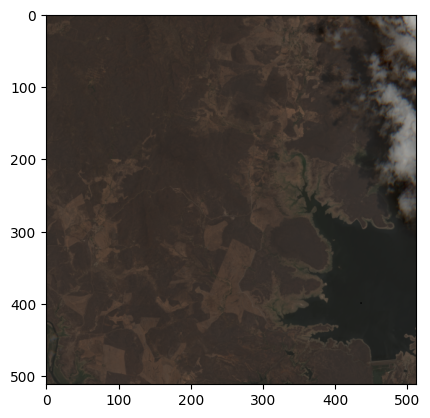

In [6]:
plt.imshow(rgb, vmin=0, vmax=1)

In [7]:
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=0, vmax=3)
# convert from 0-1:
# datan = norm(np.log(test_pred))
# datan = 
# convert to rgba:
# pred_rgba = cmap(datan)
# cmap
pred_rgb = pred_rgba[:,:3]
pred_rgb.shape

(23832, 3)

In [8]:

for r_ctr, row in test_ssc_orig.iterrows():
    i,j = int(row["row"]), int(row["col"])
    rgb_pred[i,j] = pred_rgb[r_ctr]
    # print(i,j)

In [11]:
rows = test_ssc_orig["row"].values
cols = test_ssc_orig["col"].values
rows, cols

(array([ 68, 151, 151, ..., 502, 502, 502]),
 array([378, 397, 398, ..., 463, 464, 465]))

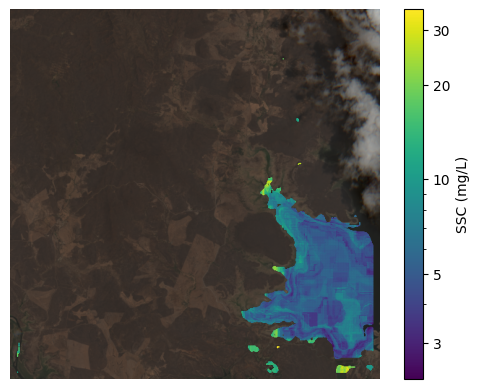

In [33]:
fig, ax = plt.subplots()
plt.imshow(rgb, vmin=0, vmax=1)
cax = ax.scatter(cols, rows, edgecolors='none', s=1, c=test_pred, norm="log")
plt.axis("off")
cbar = fig.colorbar(cax, ticks=[3, 5, 10, 20, 30, 100])
cbar.ax.set_yticklabels([3, 5, 10, 20, 30, 100])
cbar.set_label('SSC (mg/L)', rotation=90)

plt.savefig("ssc_pred.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
np.min(test_pred)

2.3055296

(array([1.4273e+04, 8.2340e+03, 5.9300e+02, 3.0500e+02, 1.4500e+02,
        1.2700e+02, 6.6000e+01, 6.0000e+01, 1.9000e+01, 1.0000e+01]),
 array([ 2.30552959,  5.55790138,  8.81027317, 12.06264496, 15.31501675,
        18.56738853, 21.81975937, 25.07213211, 28.32450294, 31.57687569,
        34.82924652]),
 <BarContainer object of 10 artists>)

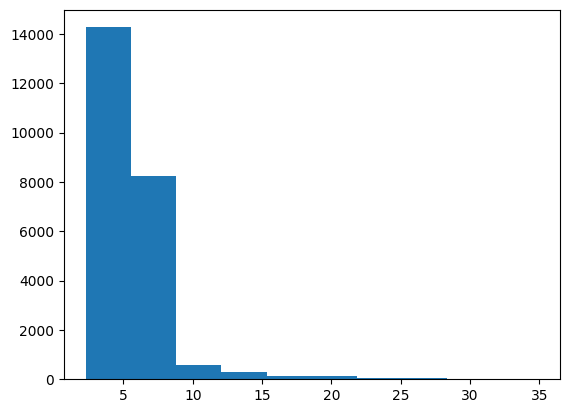

In [29]:
plt.hist(test_pred)

(array([  40., 1717., 9345., 8286., 3189.,  480.,  354.,  207.,  162.,
          52.]),
 array([0.8353104 , 1.10682511, 1.37833977, 1.64985454, 1.92136919,
        2.19288397, 2.46439862, 2.73591328, 3.00742817, 3.27894282,
        3.55045748]),
 <BarContainer object of 10 artists>)

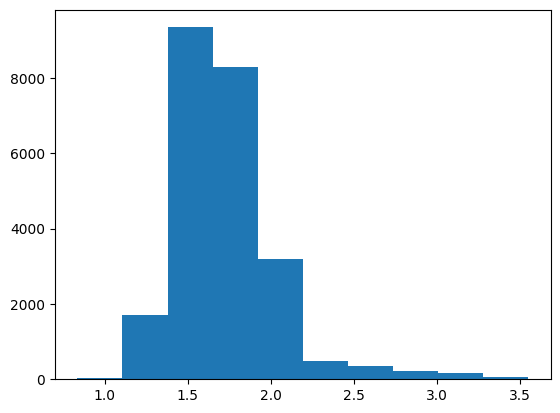

In [13]:
plt.hist(np.log(test_pred))

/tmp/ipykernel_2064414/2418182451.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('jet', 4)


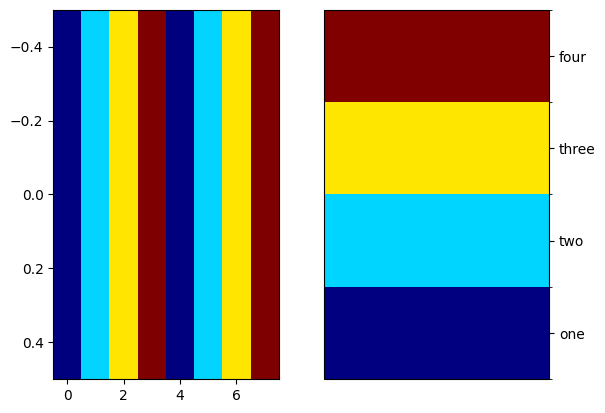

In [22]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib import colors

data = np.tile(np.arange(4), 2)
fig = plt.figure()
ax = fig.add_subplot(121)
cmap = cm.get_cmap('jet', 4)
bounds = np.arange(5)
vals = bounds[:-1]
norm = colors.BoundaryNorm(bounds, cmap.N)
ax.imshow(data[None], aspect='auto', interpolation='nearest', cmap=cmap, norm=norm)

cax = fig.add_subplot(122)
cbar = fig.colorbar(ax.images[0], cax=cax, boundaries=bounds, values=vals)
cbar.set_ticks(vals + .5)
cbar.set_ticklabels(['one', 'two', 'three', 'four'])

In [20]:
bounds

array([0, 1, 2, 3, 4])